# New complex rules across stages


## Imports


In [1]:
import os
import sys
import warnings

from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
sys.path[:0] = [os.path.abspath(".."), os.path.abspath("../..")]

import data_helper as dh
import vis_helper as vh
import complex_stages_helper as stage
import complex_stages_vis as vis


## Parameters


In [2]:
RULE_MAX_ITEMS = 4
KINDS = ["attracts", "avoids"]
MAX_FDR = 0.05
STRENGTH_METRIC = "Lift"

SCORE_COLUMN = "Pathological score"
STAGES = ["Control", "Mild", "Severe"]
ORGANS = ["Colon", "Duodenum"]

USE_CELL_ELIGIBILITY = True
MIN_CELLS_PER_TYPE = 20
MIN_RULE_FOVS = 5
TOP_RULES = 12
DETAIL_RULES = 2
NEW_MIN_STRENGTH = 1.3


TEX_RULE_EXPORTS = {
    ("attracts", "Colon", "Epithelial, Macrophage -> Plasma"): {
        "availability": "complex_epithelial_macrophage_plasma_availability.png",
        "fovs": "complex_epithelial_macrophage_plasma_colon_fovs.png",
    },
    ("attracts", "Duodenum", "Epithelial, Neuron -> Paneth"): {
        "strength": "complex_epithelial_neuron_paneth_strength.png",
        "fovs": "complex_epithelial_neuron_paneth_fovs.png",
    },
    ("attracts", "Colon", "Fibroblast, Muscle -> Neuron"): {
        "strength": "complex_fibroblast_muscle_neuron_strength.png",
        "fovs": "complex_fibroblast_muscle_neuron_fovs.png",
    },
    ("attracts", "Duodenum", "Epithelial, SMV -> Plasma_CD38"): {
        "strength": "complex_epithelial_smv_plasma_cd38_strength.png",
        "fovs": "complex_epithelial_smv_plasma_cd38_fovs.png",
    },
    ("attracts", "Duodenum", "Mesenchymal_VIM, SMV -> Endothelial"): {
        "strength": "complex_mesenchymal_smv_endothelial_strength.png",
        "fovs": "complex_mesenchymal_smv_endothelial_fovs.png",
    },
    ("avoids", "Duodenum", "Muscle -> Fibroblast, Macrophage"): {
        "strength": "complex_muscle_avoids_fibroblast_macrophage_strength.png",
        "fovs": "complex_muscle_avoids_fibroblast_macrophage_stage_fovs.png",
    },
}

TEX_OVERVIEW_EXPORTS = {
    ("attracts", "Colon"): "complex_new_colon_attracts_overview.png",
    ("attracts", "Duodenum"): "complex_new_duodenum_attracts_overview.png",
    ("avoids", "Duodenum"): "complex_new_duodenum_avoids_overview.png",
}


## Data loading


In [3]:
df_cells, df_fovs, df_biopsy = dh.load_spatial_data()
df_results = dh.load_results(
    rule_max_items=RULE_MAX_ITEMS,
    kind=None,
    max_fdr=1.0,
    informative_only=False,
)
all_rules = stage.prepare_rules(df_results, df_fovs)


Dropped 21 FOVs: Control_S


Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71


Read results_CN_pairwise.csv + results_CN_complex.csv
Loaded 1190114 rules.


Kept 1190114 rules at FDR <= 1.0.


Kept 1172931 rules naming no Unidentified.


Kept 1172931 rules (max_items=4, kind=None).


## Short analysis functions


In [4]:
def strength_label(kind):
    return STRENGTH_METRIC


def scope_label(kind):
    denominator = (
        f"{MIN_CELLS_PER_TYPE}+ cells per rule cell type"
        if USE_CELL_ELIGIBILITY else "all FOVs"
    )
    return " · ".join([
        kind,
        f"new complex rules · strength >= {NEW_MIN_STRENGTH}",
        f"stage column: {SCORE_COLUMN}",
        f"FDR <= {MAX_FDR}",
        denominator,
        f"at least {MIN_RULE_FOVS} rule FOVs in one stage",
    ])


## Results


In [5]:
vis.clear_exports([
    *TEX_OVERVIEW_EXPORTS.values(),
    *[
        filename
        for exports in TEX_RULE_EXPORTS.values()
        for filename in exports.values()
    ],
])

def show_kind(kind):
    display(Markdown(f"## {kind.title()}"))
    kind_rules = all_rules[all_rules["Kind"] == kind].copy()
    complex_rules = stage.select_complex_rules(
        kind_rules,
        max_fdr=MAX_FDR,
        new_only=True,
        min_strength=NEW_MIN_STRENGTH,
        metric=STRENGTH_METRIC,
    )
    eligibility = stage.rule_eligibility(
        complex_rules, df_cells, MIN_CELLS_PER_TYPE
    )

    for organ in ORGANS:
        display(Markdown(f"### {organ}"))
        prevalence = stage.stage_prevalence(
            complex_rules,
            kind_rules,
            eligibility,
            df_fovs,
            organ,
            STAGES,
            SCORE_COLUMN,
            MAX_FDR,
            USE_CELL_ELIGIBILITY,
        )
        top, ranked_names = stage.rank_rules(
            prevalence, STAGES, MIN_RULE_FOVS, TOP_RULES
        )
        display(stage.result_table(top, new_only=True))
        vis.plot_prevalence_overview(
            top,
            STAGES,
            organ=organ,
            params=scope_label(kind),
            save=TEX_OVERVIEW_EXPORTS.get((kind, organ)),
        )

        chosen = stage.detail_rules(
            complex_rules, ranked_names, DETAIL_RULES, new_only=True
        )
        report_rules = [
            rule
            for export_kind, export_organ, rule in TEX_RULE_EXPORTS
            if export_kind == kind and export_organ == organ and rule in ranked_names
        ]
        chosen = list(dict.fromkeys(chosen + report_rules))
        for name in chosen:
            export = TEX_RULE_EXPORTS.get((kind, organ, name), {})
            rule_prevalence = top[top["name"].astype(str) == name].copy()
            if export.get("availability"):
                availability = stage.availability_breakdown(
                    [name], complex_rules, kind_rules, eligibility, df_fovs,
                    organ, STAGES, SCORE_COLUMN, MAX_FDR,
                )
                vis.plot_availability_breakdown(
                    availability, STAGES, [name], organ=organ,
                    params=scope_label(kind), save=export["availability"],
                )
            strengths = stage.patient_strengths(
                name,
                complex_rules,
                kind_rules,
                eligibility,
                df_fovs,
                organ,
                STAGES,
                SCORE_COLUMN,
                STRENGTH_METRIC,
                USE_CELL_ELIGIBILITY,
            )
            vis.plot_prevalence_and_strength(
                rule_prevalence,
                strengths,
                STAGES,
                metric=strength_label(kind),
                organ=organ,
                params=scope_label(kind),
                new_only=True,
                save=export.get("strength"),
            )
            examples = stage.fov_examples(
                name,
                complex_rules,
                kind_rules,
                eligibility,
                df_fovs,
                organ,
                STAGES,
                SCORE_COLUMN,
                STRENGTH_METRIC,
                USE_CELL_ELIGIBILITY,
                new_only=True,
            )
            vh.plot_stage_rule_fovs(
                examples,
                STAGES,
                df_cells,
                df_fovs,
                organ=organ,
                subtitle="New complex rule",
                params=scope_label(kind),
                cell_size=11,
                save=export.get("fovs"),
            )


## Attractions


## Attracts

### Colon

,name,stage,complex prevalence
2061,"Fibroblast, Muscle -> Neuron",Control,1 / 14 (7%)
2062,"Fibroblast, Muscle -> Neuron",Mild,5 / 15 (33%)
2063,"Fibroblast, Muscle -> Neuron",Severe,2 / 12 (17%)
96,"Epithelial, Macrophage -> Plasma",Control,6 / 25 (24%)
97,"Epithelial, Macrophage -> Plasma",Mild,1 / 12 (8%)
98,"Epithelial, Macrophage -> Plasma",Severe,0 / 18 (0%)
276,"Fibroblast, Goblet -> Plasma",Control,6 / 25 (24%)
277,"Fibroblast, Goblet -> Plasma",Mild,1 / 12 (8%)
278,"Fibroblast, Goblet -> Plasma",Severe,0 / 14 (0%)
24,"Epithelial, SMV -> Plasma",Control,5 / 21 (24%)


saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_new_colon_attracts_overview.png


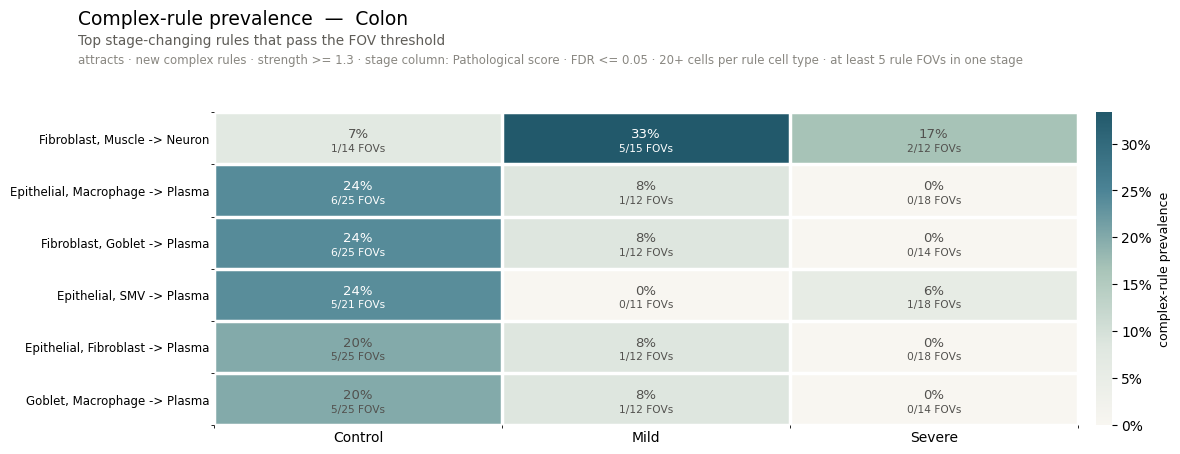

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_fibroblast_muscle_neuron_strength.png


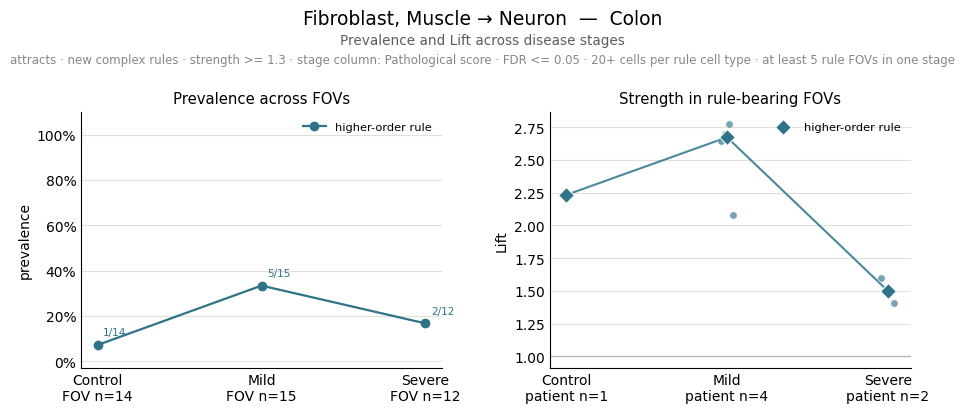

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_fibroblast_muscle_neuron_fovs.png


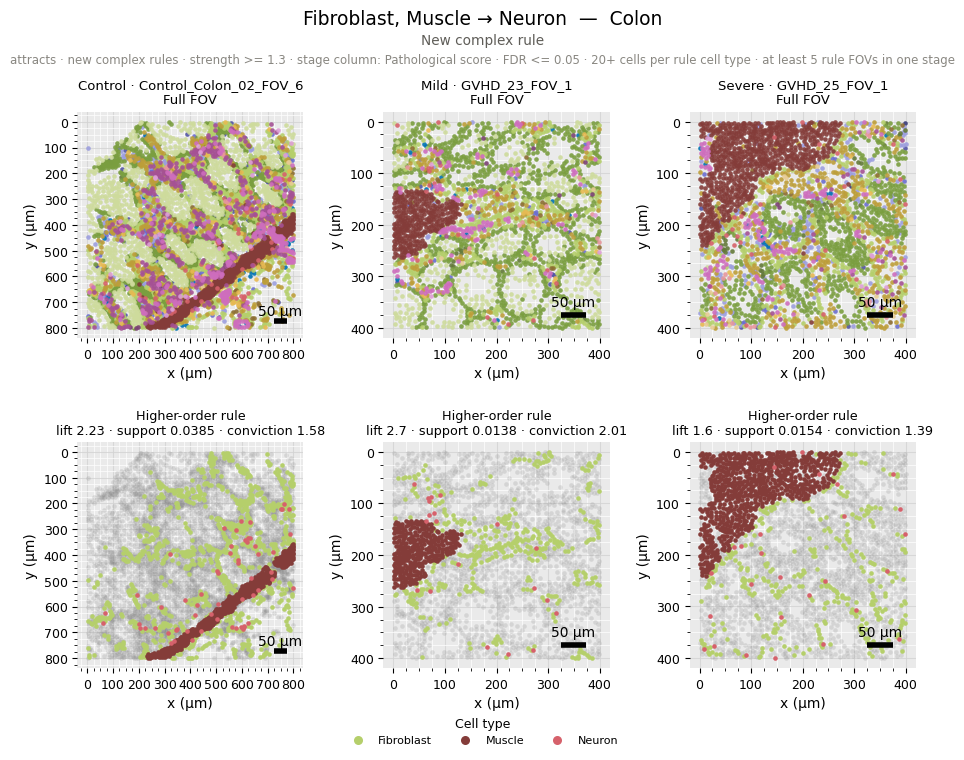

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_epithelial_macrophage_plasma_availability.png


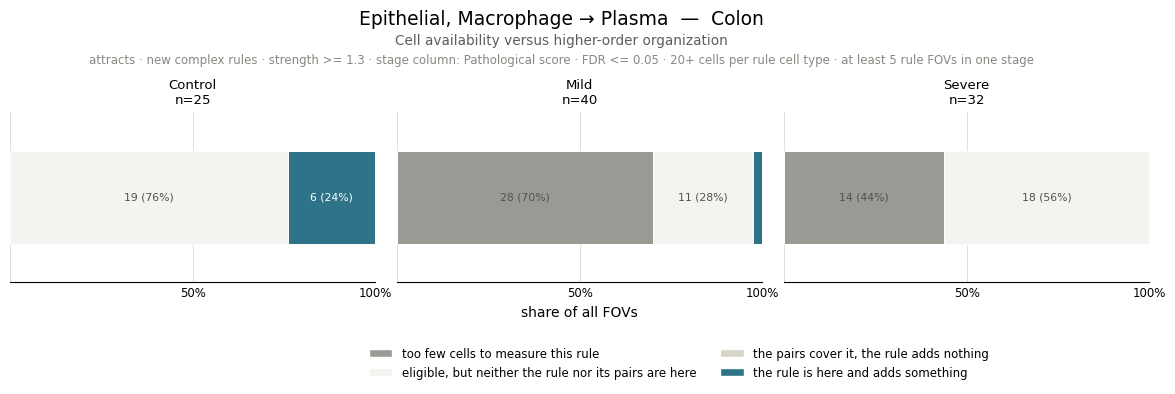

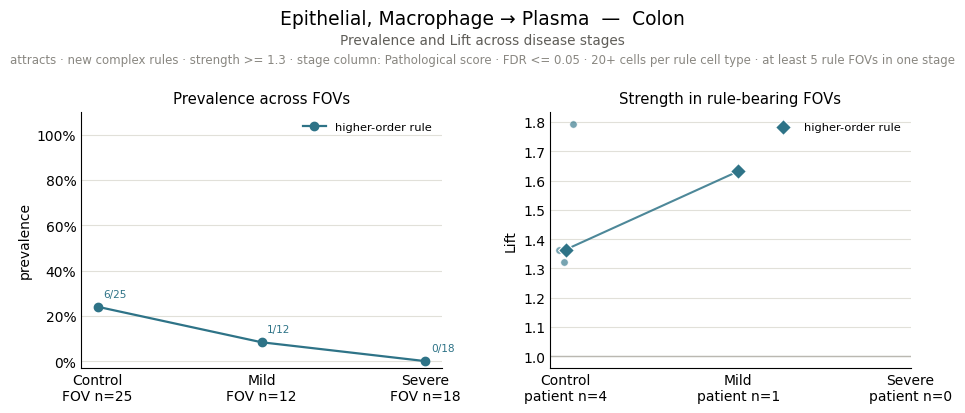

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_epithelial_macrophage_plasma_colon_fovs.png


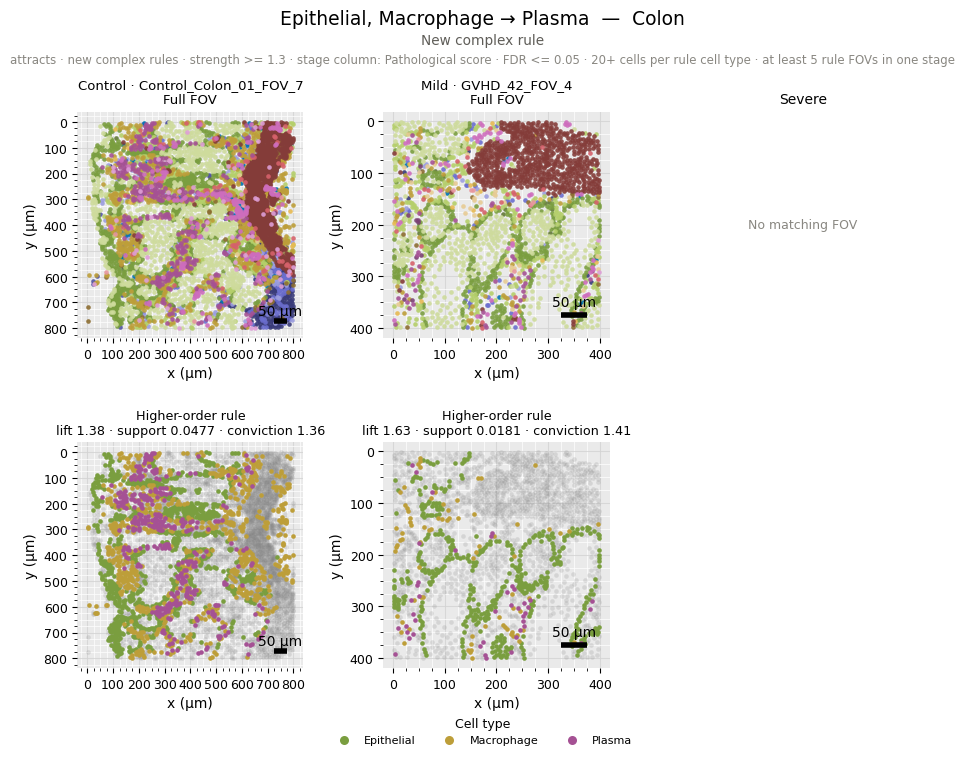

### Duodenum

,name,stage,complex prevalence
99,"Epithelial, Neuron -> Paneth",Control,3 / 11 (27%)
100,"Epithelial, Neuron -> Paneth",Mild,8 / 58 (14%)
101,"Epithelial, Neuron -> Paneth",Severe,0 / 6 (0%)
546,"Mesenchymal_VIM, SMV -> Endothelial",Control,0 / 1 (0%)
547,"Mesenchymal_VIM, SMV -> Endothelial",Mild,5 / 30 (17%)
548,"Mesenchymal_VIM, SMV -> Endothelial",Severe,0 / 18 (0%)
1545,"Epithelial, SMV -> Plasma_CD38",Control,0 / 26 (0%)
1546,"Epithelial, SMV -> Plasma_CD38",Mild,7 / 70 (10%)
1547,"Epithelial, SMV -> Plasma_CD38",Severe,3 / 22 (14%)
1782,"Epithelial, Fibroblast -> Plasma",Control,0 / 30 (0%)


saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_new_duodenum_attracts_overview.png


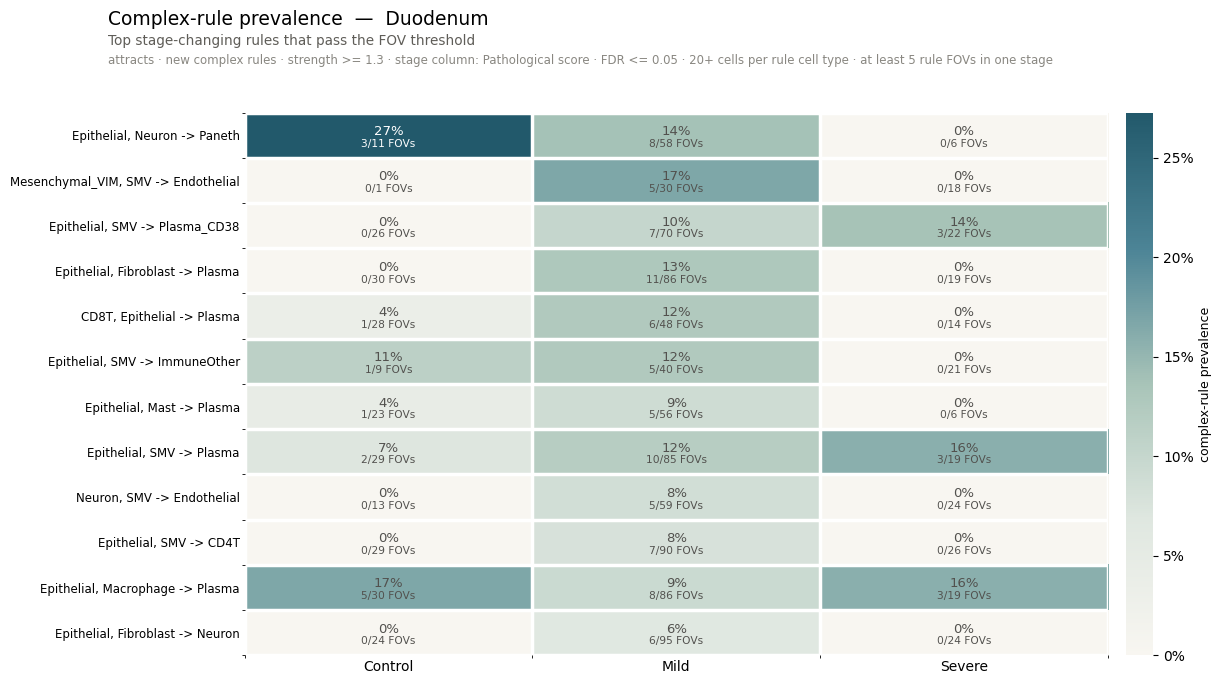

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_epithelial_neuron_paneth_strength.png


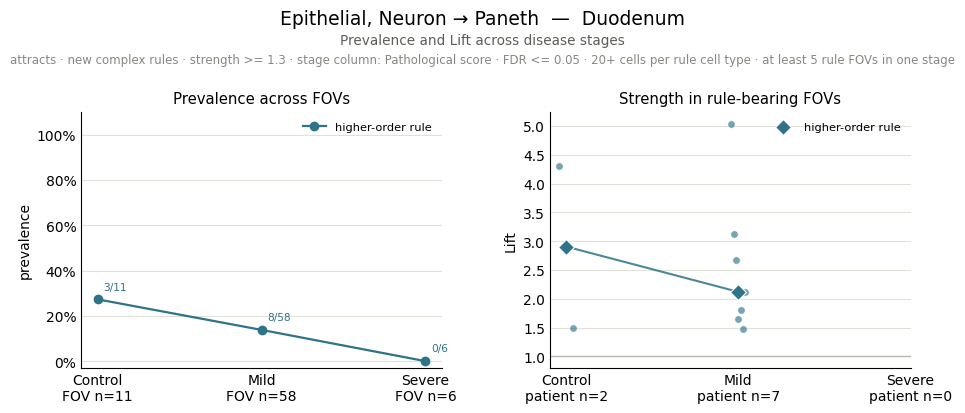

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_epithelial_neuron_paneth_fovs.png


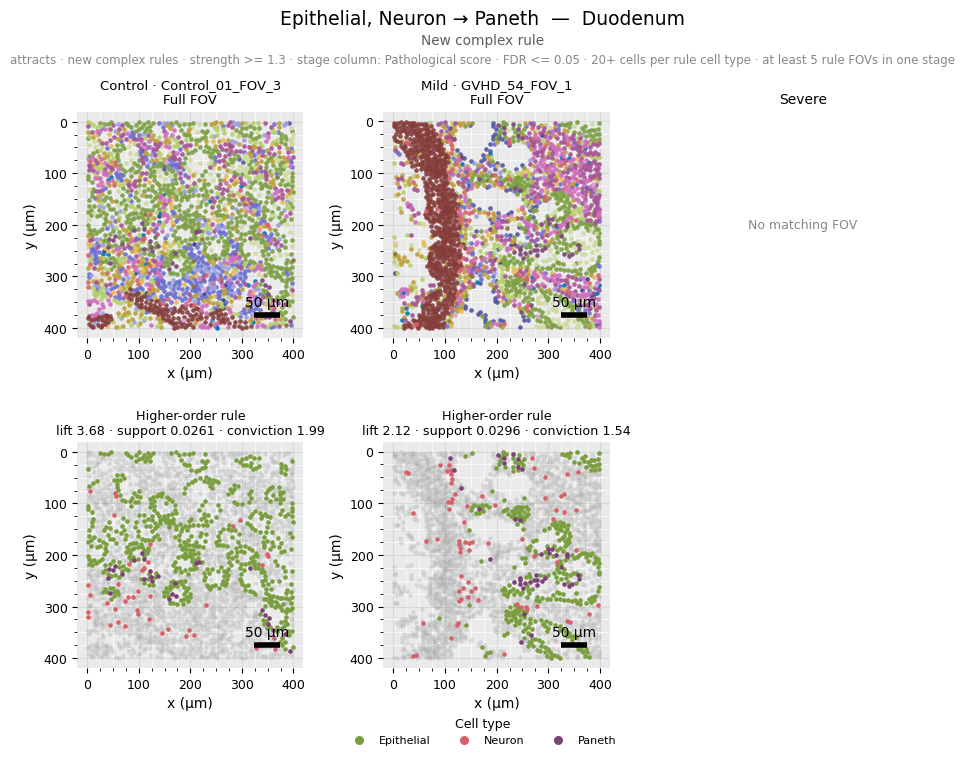

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_mesenchymal_smv_endothelial_strength.png


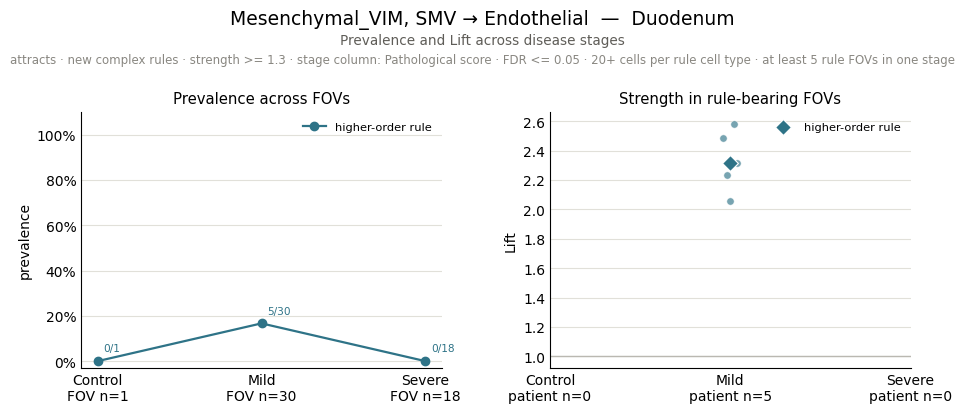

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_mesenchymal_smv_endothelial_fovs.png


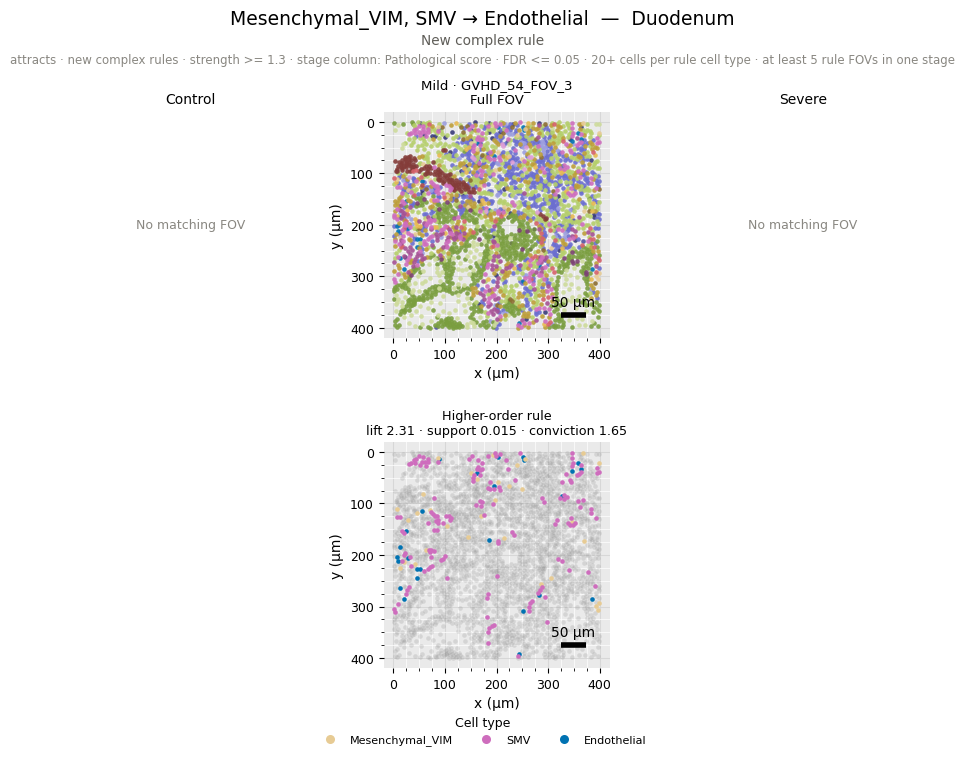

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_epithelial_smv_plasma_cd38_strength.png


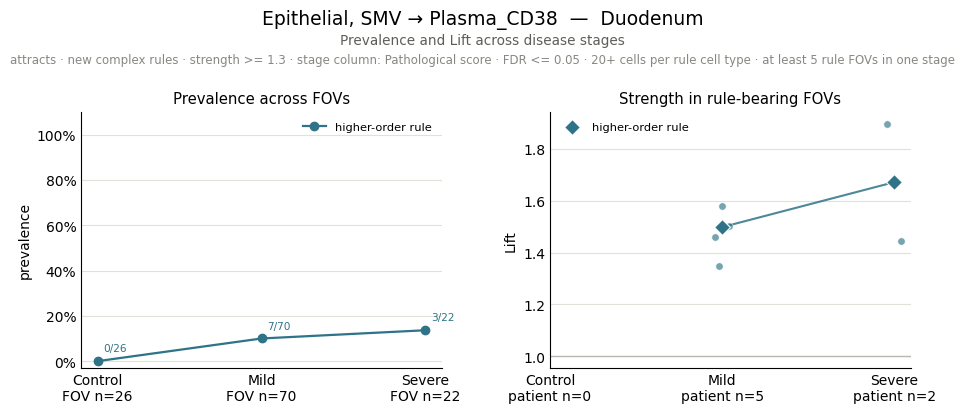

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_epithelial_smv_plasma_cd38_fovs.png


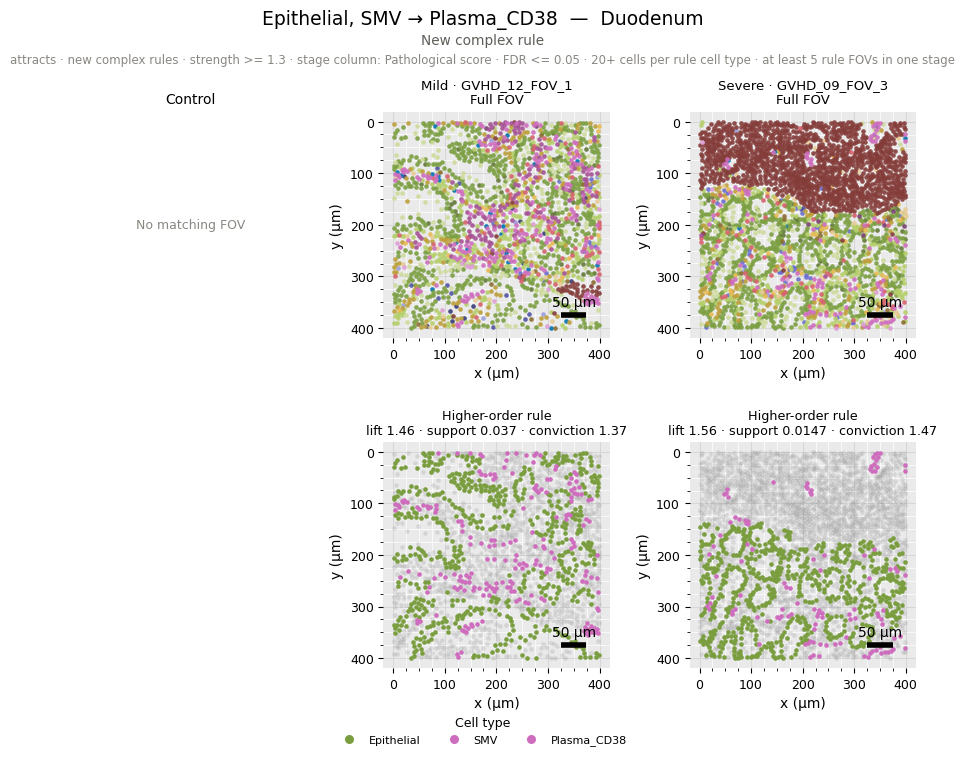

In [6]:
show_kind("attracts")


## Avoidances (negative spatial rules)


## Avoids

### Colon

,name,stage,n_fovs,complex,simpler,complex_share,simpler_share


No rules pass the FOV threshold.


### Duodenum

,name,stage,complex prevalence
2187,"Muscle -> Macrophage, SMV",Control,0 / 17 (0%)
2188,"Muscle -> Macrophage, SMV",Mild,7 / 65 (11%)
2189,"Muscle -> Macrophage, SMV",Severe,1 / 27 (4%)
1242,"Muscle, SMV -> Fibroblast",Control,0 / 17 (0%)
1243,"Muscle, SMV -> Fibroblast",Mild,6 / 65 (9%)
1244,"Muscle, SMV -> Fibroblast",Severe,1 / 27 (4%)
495,"Muscle -> Fibroblast, SMV",Control,1 / 17 (6%)
496,"Muscle -> Fibroblast, SMV",Mild,5 / 65 (8%)
497,"Muscle -> Fibroblast, SMV",Severe,0 / 27 (0%)
195,"Muscle, SMV -> Macrophage",Control,1 / 17 (6%)


saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_new_duodenum_avoids_overview.png


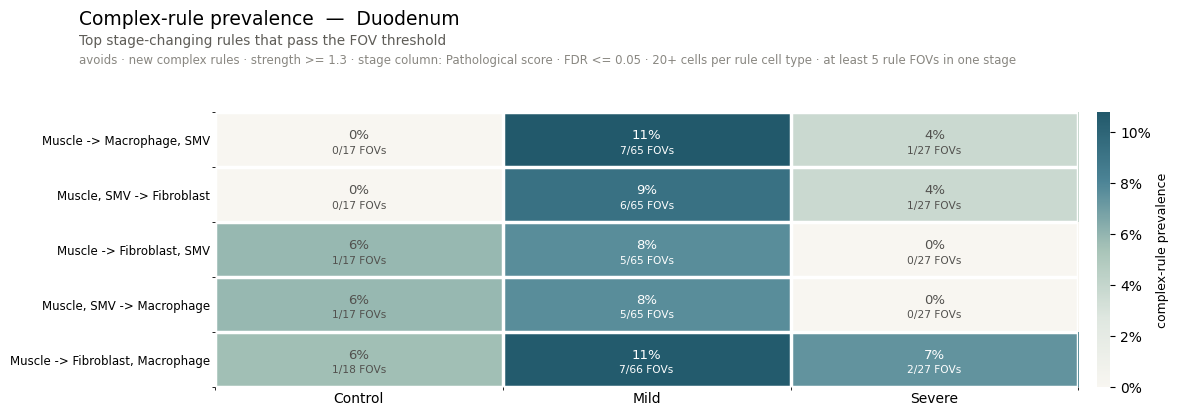

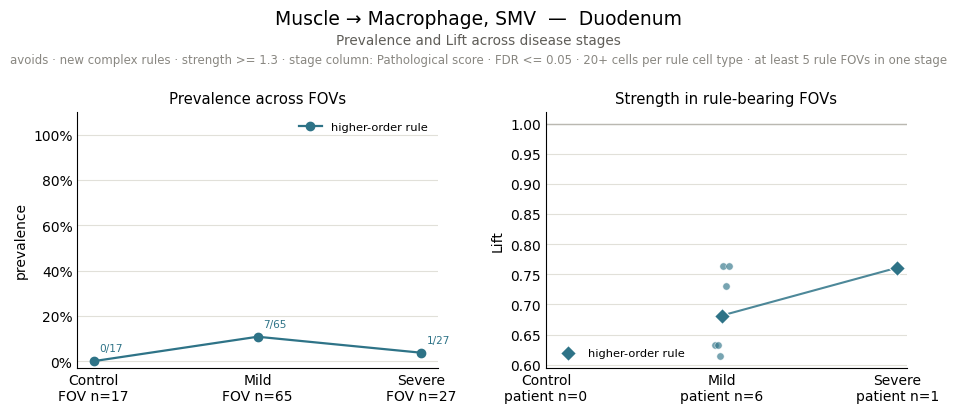

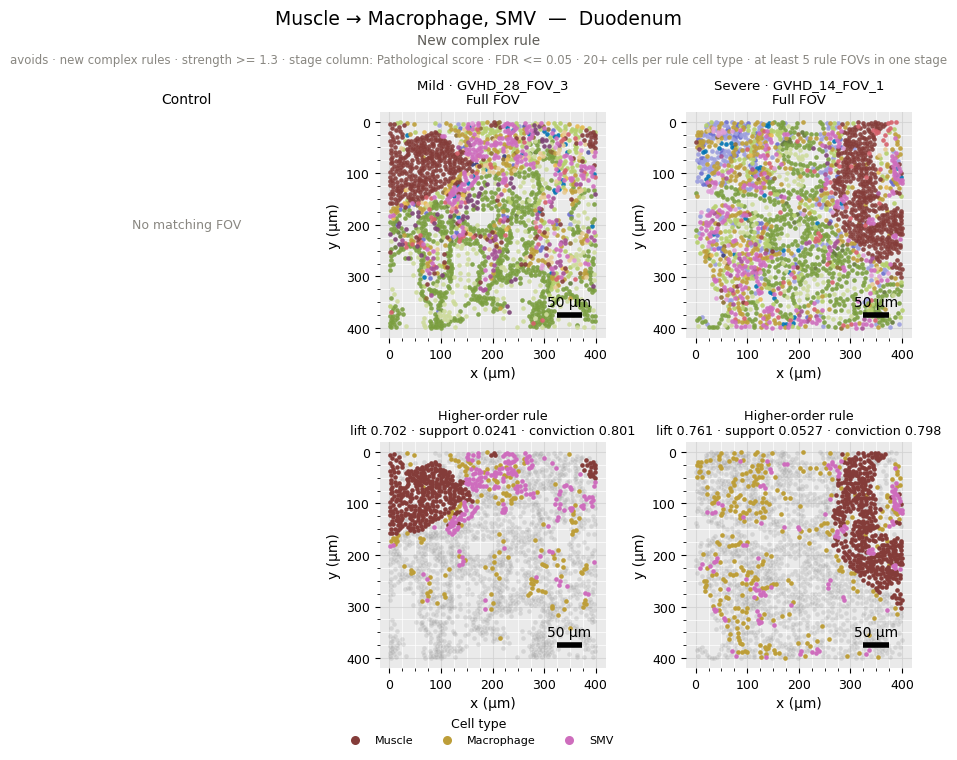

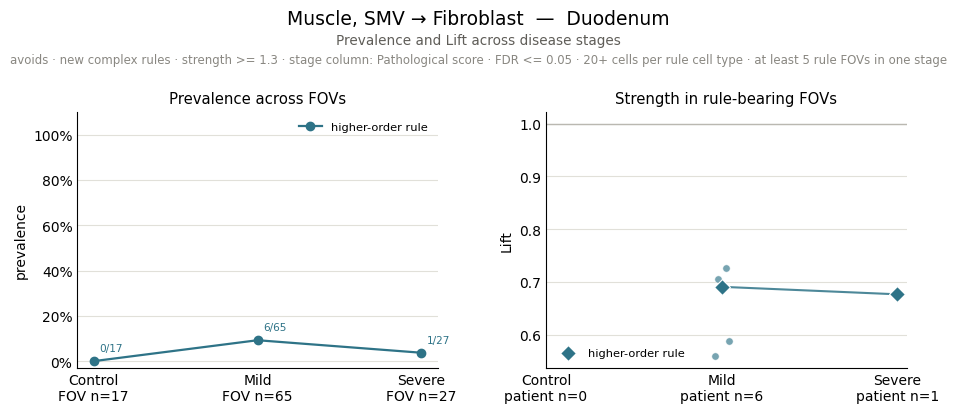

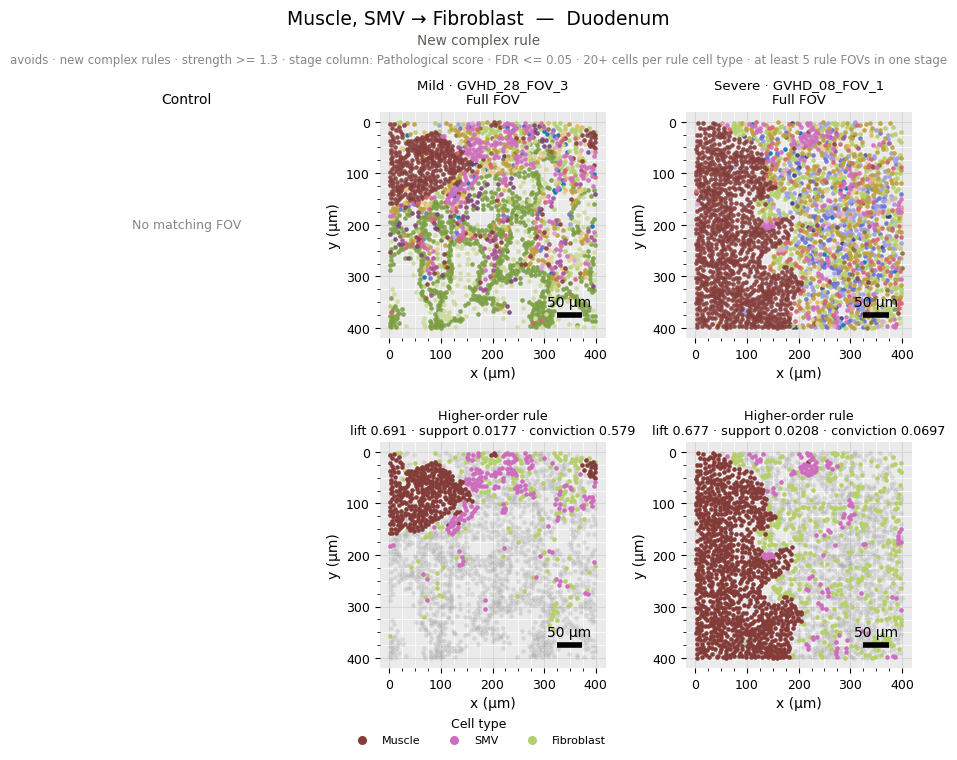

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_muscle_avoids_fibroblast_macrophage_strength.png


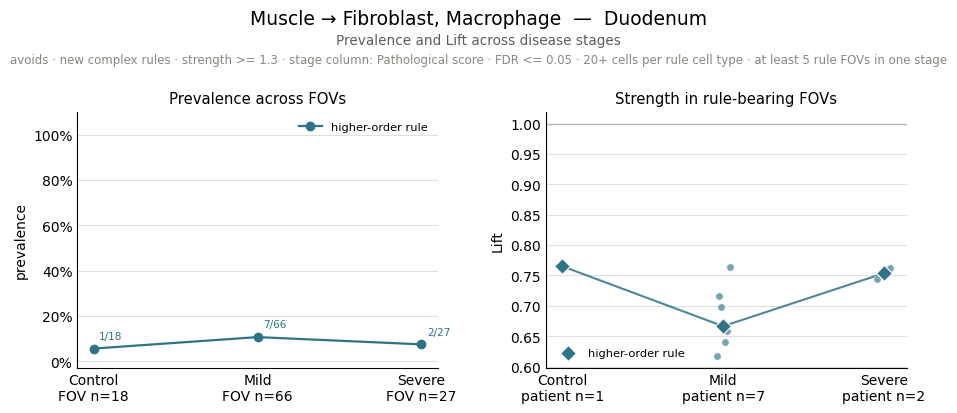

saved C:\Users\Owner\Documents\worktrees\script-rule-mining-wt-2\result_summary\complex_rules\summary_downloads\complex_muscle_avoids_fibroblast_macrophage_stage_fovs.png


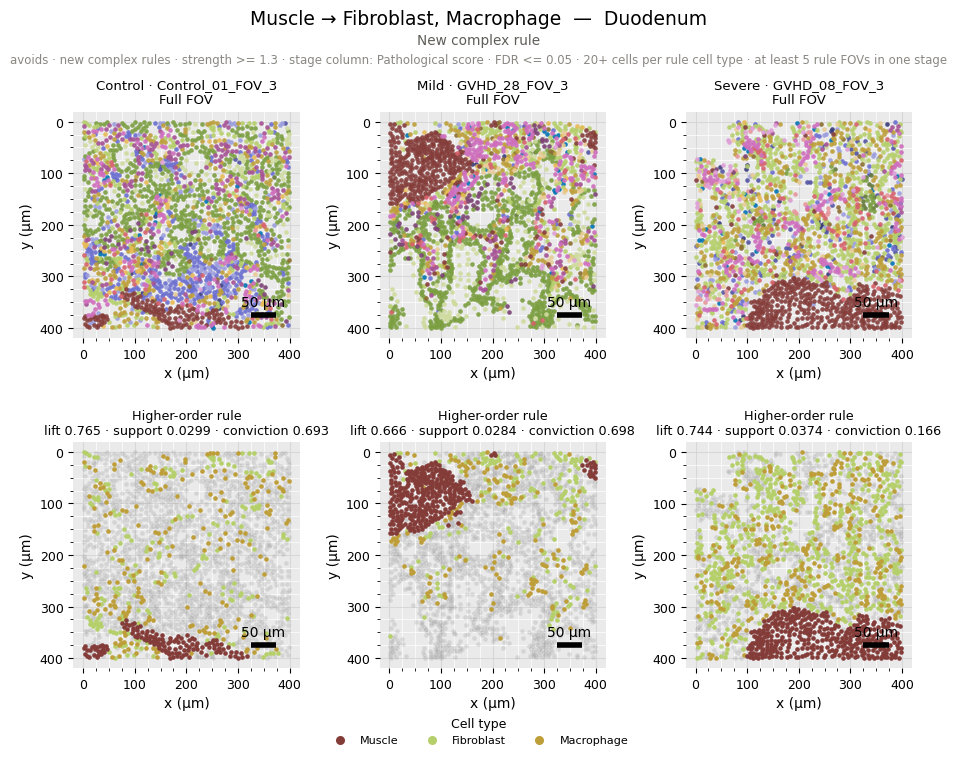

In [7]:
show_kind("avoids")
